# 3W Dataset on Sensory data predicting Well Faults

# Variable information

* JUS = jusante = downstream
* MON = montante = upstream
* CKP = choke de produção = production choke
* CKGL = choke de gas lift = gas lift choke

1. Pressure at the Permanent Downhole Gauge — deep inside the well <strong>(P-PDG)</strong>;
2. Pressure at the Topside Pressure Transducer — at surface level <strong>(P-TPT)</strong>;
3. Temperature at the Topside Pressure Transducer <strong>T-TPT</strong>;
4. Pressure upstream of the Production Choke <strong>P-MON-CKP</strong>;
5. Temperature downstream of the Production Choke <strong>T-JUS-CKP</strong>;
6. Pressure downstream of the Gas Lift Choke <strong>P-JUS-CKGL</strong>;
7. Temperature downstream of the Gas Lift Choke <strong>T-JUS-CKGL</strong>;
8. Gas Lift Flow Rate — volume of gas being injected <strong>QGL</strong>;






### Understanding Basic Terms
An oil well is essentially a pipe going deep underground. Oil and gas are trapped in rock thousands of meters below. The challenge is getting it to the surface in a controlled way.

<hr>
Downhole Gauge (PDG)
A sensor sitting deep inside the well, close to where the oil actually is. It measures pressure at the source. Think of it as taking the pulse of the reservoir itself. "Downhole" just means underground, inside the well bore.

<hr>
Transducer (TPT)
A transducer is just a device that converts a physical property (like pressure or temperature) into an electrical signal you can record. TPT sits at the top of the well, at surface level. "Topside" means above ground. So P-PDG and P-TPT are both measuring pressure, just one is deep underground and one is at the surface.

<hr>
Production Choke (CKP)
Oil and gas coming up the well is under enormous pressure. You can't just let it blast out freely — it would be dangerous and uncontrollable. The production choke is essentially an adjustable valve that restricts the flow, controlling how fast oil comes out. Think of it like a tap. Measuring pressure before (upstream) and after (downstream) the choke tells you how much pressure is being lost across it, which reveals if something is wrong with flow.

<hr>
Gas Lift Choke (CKGL)
Sometimes a well doesn't have enough natural pressure to push oil to the surface on its own. Gas lift solves this by injecting gas down into the well, which lightens the column of fluid and helps push oil up — like blowing air into a straw submerged in water. The gas lift choke controls how much of that injected gas goes in. QGL is literally measuring how much gas is flowing through this choke.


## Purpose of model
The purpose of this models is to detect the possible occurence of faults in oil wells. 

The transient classes will be the most important classes in this dataset. The model detects faults before they occur, not to identify the fault after they occur. 

Target accuracy : > 0.97

##  Labels information

BSW (class 1) — water and sediment suddenly mixing into the oil flow. Bad for equipment and product quality.
<hr>
Incipient leak (class 2) — a small, developing leak in the production choke valve before it becomes a full rupture.
<hr>
Flow instability (class 3) — the flow oscillates unpredictably instead of being steady. Often caused by gas-liquid slugging.
<hr>
Rapid productivity loss (class 4) — the well suddenly starts producing much less oil, usually due to reservoir or damage issues.
<hr>
Quick restriction in choke (class 5) — something is partially blocking the production choke, reducing flow.
<hr>
Scaling (class 6) — mineral deposits building up inside the choke, slowly narrowing it.
Hydrate in production line (class 7) — ice-like crystals forming in the production pipe and blocking flow.
<hr>
Hydrate in service line (class 8) — same hydrate problem but in the service/gas lift line instead.

### Undertsanding classes

<strong>Class 0 — Normal Operation</strong>
The well is producing steadily. Reservoir pressure drives oil up through the wellbore, through the production choke, into the pipeline. All sensors are stable with low variance. P-TPT and P-MON-CKP hold steady, temperatures are consistent. This is your baseline — every fault class is defined by how it deviates from this state.
<hr>

<strong>Class 1 — Abrupt Increase of BSW (Basic Sediment & Water)</strong>
BSW is the percentage of water and sediment mixed into the produced oil. Normally a well produces mostly oil with some water. In this fault, water suddenly breaks through from the reservoir in large quantities.
What happens physically: The reservoir has an oil zone sitting on top of a water zone. Over time, or due to production strategy, water breaks through into the wellbore. Suddenly you're pumping mostly water instead of oil.
Sensor signature:

* P-PDG drops — water is heavier than oil, changing the pressure gradient
* Temperature changes — water has different thermal properties than oil
* The transition is abrupt, not gradual

Why it matters: Water is corrosive, damages downstream equipment, reduces production value dramatically, and increases processing costs.
<hr>

<strong>Class 2 — Incipient Leak in Production Choke</strong>
A small, developing crack or seal failure in the production choke valve — before it becomes a full rupture.
What happens physically: The choke valve body or seat develops a small leak, allowing fluid to bypass the controlled flow path. Flow is no longer fully controlled by the valve position.
Sensor signature:

* P-MON-CKP (upstream pressure) behaves unexpectedly relative to choke position
* Flow rate becomes inconsistent with expected values
* The pressure differential across the choke changes subtly

Why it matters: A small leak escalates into a full choke failure if undetected. Choke replacement offshore is extremely expensive and requires production shutdown.
<hr>

<strong>Class 3 — Flow Instability</strong>
The well flow oscillates in cyclic patterns instead of flowing steadily. Also called slugging.
What happens physically: Oil and gas don't flow as a uniform mixture. Instead they segregate — gas accumulates, builds pressure, then releases suddenly pushing a slug of liquid through the pipe. This creates a repeating cycle of high flow/low flow.
Sensor signature:

This is the most periodic fault — all sensors oscillate rhythmicall:
* P-TPT and P-MON-CKP show regular peaks and troughs
* Temperature oscillates in sync with pressure
* Std and variance features will be very high for this class

Why it matters: Slugging causes severe mechanical stress on equipment, damages compressors and separators downstream, and makes production measurement unreliable.

<hr>

<strong>Class 4 — Rapid Productivity Loss</strong>
The well suddenly starts producing significantly less oil than expected given the operating conditions.
What happens physically: Several possible causes — reservoir damage near the wellbore (skin damage), scale or wax deposition deep in the well, or a sudden change in reservoir connectivity. The well loses its ability to deliver fluid efficiently.
Sensor signature:

* QGL increases as operators inject more gas lift to compensate
* P-PDG drops as reservoir deliverability falls
* P-TPT drops as less fluid reaches the surface
* The decline is rapid — happening over hours not weeks

Why it matters: Directly impacts production revenue. Early detection allows intervention before permanent reservoir damage occurs.

<hr>

<strong>Class 5 — Quick Restriction in Production Choke</strong>
Something partially blocks the production choke suddenly — reducing the flow opening without the operator changing the choke setting.
What happens physically: Debris, wax, scale, or a mechanical failure partially closes the choke. The effective flow area shrinks suddenly.
Sensor signature:

* P-MON-CKP (upstream of choke) increases — pressure builds up behind the restriction
* P-TPT (downstream/topside) decreases — less fluid getting through
* The pressure differential across the choke increases sharply
* This pressure differential (P-MON-CKP minus P-TPT) is potentially a very powerful engineered feature for this class specifically

Why it matters: Reduces production rate, can escalate to complete blockage, and puts mechanical stress on the choke.

<hr> 

<strong>Class 6 — Scaling in Production Choke</strong>
Mineral deposits (scale) slowly build up inside the production choke, gradually narrowing the flow path.
What happens physically: Produced water contains dissolved minerals — calcium carbonate, barium sulphate etc. As conditions change (pressure drop, temperature change) across the choke, these minerals precipitate out and deposit on the choke walls. Unlike class 5 this is a slow, progressive restriction.
Sensor signature:

Similar to class 5 but develops gradually over days/weeks not suddenly
* P-MON-CKP slowly increases over time
* Slope features are particularly important here — slow upward trend in upstream pressure
* Std remains relatively low because the change is gradual not erratic

Why it matters: If undetected, scaling completely blocks the choke requiring expensive intervention. Chemical treatment is cheap if caught early.

<hr>

<strong>Class 7 — Hydrate in Production Line</strong>
Ice-like crystals form inside the production pipeline and start blocking flow.
What happens physically: Natural gas + water + high pressure + low temperature = hydrates. They look like ice but form at temperatures well above 0°C under pressure. They can block a pipeline completely within hours.
Sensor signature:

* Temperature is the critical sensor — T-TPT and T-JUS-CKP drop toward the hydrate formation temperature
* Pressure upstream of the blockage increases as the hydrate grows
* Pressure downstream drops as flow is restricted
* QGL often increases as operators try to maintain flow
  
Month/season is a strong predictor — hydrates form more easily in cold months

Why it matters: Hydrate plugs are one of the most dangerous and costly problems in offshore production. Clearing a hydrate plug can take days and costs millions.

<hr> 

<strong>Class 8 — Hydrate in Service Line</strong>
Same hydrate physics as class 7 but occurring in the gas lift injection line rather than the production line.
What happens physically: The gas being injected for gas lift is cold and high pressure — ideal hydrate formation conditions. As it travels down the service line to the injection point, hydrates can form and block the gas lift system.
Sensor signature:

* P-JUS-CKGL drops or becomes erratic — gas lift pressure is disrupted
* QGL drops — less gas getting through to the injection point
* The production line sensors (P-TPT, P-MON-CKP) then react secondarily as gas lift effectiveness drops
* T-JUS-CKGL would have been the primary indicator — but that's your missing sensor

Why it matters: When gas lift is blocked, wells with insufficient natural pressure stop producing entirely. Losing gas lift = losing production.

## Importing Libraries 📚 

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import pathlib 
import gc

In [2]:
pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 3.6 MB/s  0:00:02m 3.4 MB/s eta 0:00:01
  Attempting uninstall: scikit-learn━━━━━━━━━━━━━━━━━━ 0/2 [narwhals]
    Found existing installation: scikit-learn 1.8.0 0/2 [narwhals]
    Uninstalling scikit-learn-1.8.0:━━━━━━━━━━━━━━ 0/2 [narwhals]
      Successfully uninstalled scikit-learn-1.8.0━ 0/2 [narwhals]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scikit-learn]0m 1/2 [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


## Feature engineering functions

### Adding rolling window feature
This will be done to get more information on the data like the std, variance, range and mean.

* STD : Tells the model how far the data point is from the mean, a high std means the pressure (for example) spiked from the normal/average pressure. For fault detection this is arguably the most powerful feature. A pressure that is normally std=0.2 suddenly jumping to std=3.0 is a red flag, even before the mean shifts significantly.
* MEAN: This is the average value over the past window. shows the average value over that time period. If this starts drifting lower over successive windows, something is changing in the well.
* VARIENCE : std squared. Carries the same information as std but amplifies larger deviations because of the squaring. A deviation of 2 contributes 4 to variance, a deviation of 5 contributes 25 = 1.14 bar².
* RANGE: Max - Min. Small range value shows there is no sudden change or spike.
* EWN (Exponential weighting): The most recent row gets the most weight. Weight decays exponentially as you go further back. This is very useful for sensor data because it means the most recent reading matters most — which makes physical sense. A pressure reading from 10 minutes ago is less relevant than the reading from 1 minute ago.


In [2]:
def roll_win(df):
    df = df.reset_index()

    # Adding cyclic windows. Using sin and cos instead of month numbers e.g 1 for jan, 2 for feb, so the model will
    # see the jan and dec arent far apart at all like it will portray mathematically (1 and 12 are far)
    df["month"] = df["timestamp"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df = df.drop(columns=["month"])
    df = df.set_index("timestamp")
    df = df.sort_index()
    for col in ['P-PDG','P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL', 'QGL']:
        # 10-minute statistics
        df[f"{col}_mean_10min"] = (
            df[col]
            .rolling(window="10min", min_periods=10)
            .mean()
        )
        df[f"{col}_var_10min"] = (
            df[col]
            .rolling(window="10min", min_periods=10)
            .var()
        )
        df[f"{col}_std_10min"] = (
            df[col]
            .rolling(window="10min", min_periods=10)
            .std()
        )
        df[f"{col}_range_10min"] = (
            df[col]
            .rolling(window="10min", min_periods=10)
            .max()
            -
            df[col]
            .rolling(window="10min", min_periods=10)
            .min()
        )
        # 120-minute statistics
        df[f"{col}_mean_120min"] = (
            df[col]
            .rolling(window="120min", min_periods=120)
            .mean()
        )
        df[f"{col}_std_120min"] = (
            df[col]
            .rolling(window="120min", min_periods=120)
            .std()
        )
    for col in ['P-PDG','P-TPT', 'P-MON-CKP', 'P-JUS-CKGL', 'QGL']:
        df[f"{col}_ewm"] = df[col].ewm(span=10).mean()  # EWM for pressure columns

        
    cleared_objs = gc.collect()
    print(f"Cleared {cleared_objs} trapped objects from RAM")
    return df

In [3]:
def preproccesing(df):
    """
    Creates additional columns to explain more information on the data.
    Arugments : dataframe
    
    Returns : processed dataframe
    """

    df = df.sort_index()
    
    '''
    In a healthy well, downhole pressure is always higher than topside. 
    This ratio should always be greater than 1. When it drops below 1 something is wrong. 
    Clip it between 0 and 1 for stability:
    '''
    df["P-PDG_P-TPT_ratio"] = (df["P-PDG"] / (df["P-TPT"] + 1)).clip(0,1)
    
    
    '''
    When water breaks through, temperature and pressure decouple — pressure drops while temperature
    shifts independently. The ratio of temperature to pressure captures this divergence:
    '''
    df["T_P_divergence"] = df["T-TPT"] / (df["P-TPT"] + 1)
    
    '''
    A leaking choke loses its ability to maintain the pressure difference between upstream and downstream. 
    The differential should be large and stable during normal operation — a leak causes it to collapse or fluctuate:
    
    
    Std captures fluctuation — but std and this differential capture different things. Std tells you how much it's moving. 
    The differential tells you the absolute magnitude of the pressure drop across the choke. Both matter.
    '''
    df['choke_pressure_diff'] = df['P-MON-CKP'] - df['P-TPT']

    '''
    When a well loses productivity, operators instinctively increase gas lift to compensate. 
    So QGL rises while P-TPT falls — the ratio captures this inverse relationship (for class 4)
    '''
    df['productivity_index'] = df['P-TPT'] / (df['QGL'] + 1)

    '''
    Claude suggested this: Hydrates form when temperature drops toward a threshold — roughly 15–20°C at typical well pressures. 
    Distance from that danger zone is the key signal:
    '''
    df['hydrate_risk'] = df['T-JUS-CKP'] - 20  # distance from hydrate threshold
    
    '''
    Claude suggested this: Slugging creates rhythmic oscillations. The rolling std already captures this but a 
    direct measure of oscillation — how much pressure reverses direction within a window — adds something different
    
    This counts how many times the pressure reverses direction in the last 10 minutes. 
    High sign changes = oscillating = slugging. Normal flow = near zero sign changes.
    
    '''
    df['P_TPT_diff'] = df['P-TPT'].diff()
    
    # Find where current diff and previous diff have different signs (multiply to negative)
    is_sign_change = (df['P_TPT_diff'] * df['P_TPT_diff'].shift(1)) < 0
    
    df['P_TPT_sign_changes'] = is_sign_change.rolling(10, min_periods=1).sum()
    
    # 3. Vectorized Rolling Linear Regression Slope (Replaces np.polyfit)
    x_index = pd.Series(np.arange(len(df)), index=df.index)
    
    rolling_y = df['P-MON-CKP'].rolling(60, min_periods=10)
    
    rolling_x = x_index.rolling(60, min_periods=10)

    # Slope = Covariance(x, y) / Variance(x)
    df['P_MON_CKP_slope_60'] = (rolling_y.cov(x_index) / rolling_x.var())


    # 60  minute rolling window.
    df['P_TPT_std_60'] = df['P-TPT'].rolling('60min', min_periods=1).std()
    df['T_TPT_std_60'] = df['T-TPT'].rolling('60min', min_periods=1).std()
    
    # Creating stable Temp and Pressure column
    df['all_stable'] = (
        (df['P-TPT'].between(80, 140)) &
        (df['T-TPT'].between(50, 130)) &
        (df['P-MON-CKP'].between(10, 50))
    ).astype(int)
    
    # Stability streak finding the stabe
    df['stability_streak'] = df['all_stable'].groupby( 
        (df['all_stable'] != df['all_stable'].shift()).cumsum()
    ).cumcount()
    
    '''
    This finds the stability of the sensor values. 
    it firsts shifts the values of the "all_stable" once, and compares it with the original "all_stable" column 
    and adds up the True values cumulatively. Every time a change is detected, the group number increments. 
    This creates a unique group ID for each consecutive run. Within each group, 
    cumcount() counts how many rows have passed since the group started. Starts at 0:
    '''
    df = df.replace([np.inf, -np.inf], np.nan)
    cleared_objs = gc.collect()
    print(f"Cleared {cleared_objs} trapped objects from RAM")

    return df

### Extract csv files and merge 


### Observation 1: 

To prevent "data leakage" and false mathematical slopes between different wells and isolated simulations, missing values must be handled *before* the datasets are merged.

* **Timestamp Indexing:** Setting the timestamp as the index ensures that the interpolation math strictly follows chronological elapsed time (`method='time'`).
* **Handling `P-PDG` Failures:** Because power losses cause the Permanent Downhole Gauge (`P-PDG`) to output a literal 0, these false 0s are converted to `NaN`s so the model doesn't interpret them as catastrophic pressure drops.


* **Strict Interpolation Limits:**
* **Surface Sensors (`P-MON-CKP`, `T-JUS-CKP`, `T-TPT`):** Physical properties like temperature change gradually. Gaps are interpolated with a conservative 10-minute limit (600 seconds) to bridge minor sensor dropouts smoothly.
* **Downhole Sensor (`P-PDG`):** Since the downhole environment is highly volatile and failure-prone, interpolation is restricted to a strict 1-minute limit (60 seconds) to avoid fabricating data during major tool failures. The P-PDG is the downhole gauge, sitting deep inside the well. Unlike surface sensors, it's in an extremely harsh environment — high pressure, high temperature, constant vibration, corrosive fluids. It is by far the most failure-prone sensor in the entire setup because:  It's physically inaccessible — you can't just swap it out without a workover operation which is expensive The electrical cable running from deep underground to the surface degrades over time Power supply interruptions to the downhole tool would cause it to read exactly 0, not NaN — because 0 is the default output when the tool loses power or signal


* **Dropping Unrecoverable Data:** Any gaps that exceed these limits represent a prolonged loss of visibility. These rows are dropped entirely to prevent the model from training on hallucinated data.

* **T-JUS-CKP** (50,913,215) which has no values, That means the temperature sensor simply wasn't installed on any of these wells. There is no data to validate any estimate against, hence the column will be dropped.

* **T-TPT** is the temperature reading in electrical signals of the natural gas. these signals are gotten from the tranducer, which displays also the pressure of the gas. Since, the pressure is being read, it would most likely be a sensor failure.

In [4]:
def process_file(file):
    """
    Data cleaning, resampling and feature engineering block
    Arguemnts: 
    file : file path. must be a csv file. File also contains oil dataset. 
    """
    
    df = pd.read_csv(f'{file}')
    df["timestamp"] = pd.to_datetime(df["timestamp"])  # Convert the timestamp column to datetime format.
    df = df.sort_values("timestamp")
    df =  df.set_index("timestamp")

    # Strip extra spaces from column names immediately
    df.columns = df.columns.str.strip()

    # Remove T-JUS-CKGL entirely (it has zero values across all files)
    df = df.drop(columns=["T-JUS-CKGL"], errors='ignore')

    # ---------------------------------------------------------
    # THE DATA CLEANING BLOCK
    # ---------------------------------------------------------
    
    # 1. Handle P-PDG 0s
    df['P-PDG'] = df['P-PDG'].replace(0, np.nan)

    # 2. Interpolate Surface Sensors (10-minute limit = 600 seconds)
    cols_to_interpolate = ['P-MON-CKP', 'T-JUS-CKP', 'T-TPT', 'P-TPT']
    df[cols_to_interpolate] = df[cols_to_interpolate].interpolate(method='time', limit=600)

    # 3. Interpolate Downhole Sensor (1-minute limit = 60 seconds)
    df['P-PDG'] = df['P-PDG'].interpolate(method='time', limit=60)

    # 4. Create Missing Indicator Flag & Fill Remaining NaNs for Random Forest
    df['P-PDG_is_missing'] = df['P-PDG'].isna().astype(int)
    
    # 5. Inject your Gas Lift logic here
    df["gas_lift_active"] = df["QGL"].notna().astype(int) 
    df["QGL"] = df["QGL"].fillna(0) 
    df["P-JUS-CKGL"] = df["P-JUS-CKGL"].fillna(0)

    # 6. Drop all remaining unrecoverable NaN rows
    df = df.dropna(subset=[
        'P-MON-CKP',
        'T-JUS-CKP',
        'T-TPT',
        'P-TPT'
    ])

    # ---------------------------------------------------------
    # THE CORRECTED RESAMPLING BLOCK
    # ---------------------------------------------------------
    # Resample data to 5mins groups
    feature = (
            df.drop(columns="class")
            .resample("30s")
            .agg('mean')
    )
    
    label = df["class"].resample("30s").last()
    df = feature.join(label)

    df = df.dropna(subset=["class"])

    path = pathlib.Path(file)
    # Create Instance_id column to signify values for each well instance.
    df["Instance_id"] = f"{path.parent.name}_{path.stem}"

    # ---------------------------------------------------------
    # THE PREPROCESSING AND FEATURE ENGINERRING BLOCK
    # ---------------------------------------------------------
    # 7. Safely execute rolling windows and feature engineering on compressed data
    df = roll_win(df)
    df = preproccesing(df)

    return df

In [5]:
def merge_csv(csv_list):
    return pd.concat(csv_list)
        

In [ ]:
# Loop through all folders and group the timestamps by the date

for folder in range(9):
    folder_path = pathlib.Path(f'../data/{folder}')
    if folder_path.is_dir():
        csv_list = []
        for i, file in enumerate(sorted(folder_path.glob('*.csv'))): # loop through each sorted file and process the file
            if file.is_file():
                try:
                    file = str(file)
                    df = process_file(file)
                    df = df.sort_index()
                    csv_list.append(df)
                except Exception as e:
                    print(f"Error processing folder {file} : {e}")
        csv_file = merge_csv(csv_list)
        output_path = pathlib.Path(f'../resampled_csv/{folder}')
        output_path.mkdir(parents=True, exist_ok=True)
        csv_file.to_csv(output_path / f'compressed_{folder}.csv')


Cleared 1209 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped objects from RAM
Cleared 0 trapped

In [11]:
class_labels = {
    0: "Normal Operation",
    1: "Abrupt Increase of BSW",
    2: "Incipient Leak in Production Choke",
    3: "Flow Instability",
    4: "Rapid Productivity Loss",
    5: "Quick Restriction in Production Choke",
    6: "Scaling in Production Choke",
    7: "Hydrate in Production Line",
    8: "Hydrate in Service Line",

    101: "Transient - Abrupt Increase of BSW",
    102: "Transient - Incipient Leak in Production Choke",
    103: "Transient - Flow Instability",
    104: "Transient - Rapid Productivity Loss",
    105: "Transient - Quick Restriction in Production Choke",
    106: "Transient - Scaling in Production Choke",
    107: "Transient - Hydrate in Production Line",
    108: "Transient - Hydrate in Service Line",
}

In [12]:
class_labels

{0: 'Normal Operation',
 1: 'Abrupt Increase of BSW',
 2: 'Incipient Leak in Production Choke',
 3: 'Flow Instability',
 4: 'Rapid Productivity Loss',
 5: 'Quick Restriction in Production Choke',
 6: 'Scaling in Production Choke',
 7: 'Hydrate in Production Line',
 8: 'Hydrate in Service Line',
 101: 'Transient - Abrupt Increase of BSW',
 102: 'Transient - Incipient Leak in Production Choke',
 103: 'Transient - Flow Instability',
 104: 'Transient - Rapid Productivity Loss',
 105: 'Transient - Quick Restriction in Production Choke',
 106: 'Transient - Scaling in Production Choke',
 107: 'Transient - Hydrate in Production Line',
 108: 'Transient - Hydrate in Service Line'}

### Create one large dataset


In [ ]:
label_datasets = []

for i in range(9):
    class_df = pd.read_csv(f'../resampled_csv/{i}/compressed_{i}.csv')
    label_datasets.append(class_df) # join sub-datasets together

dataset = pd.concat(label_datasets, ignore_index = True)

dataset["timestamp"] = pd.to_datetime(dataset["timestamp"])

In [12]:
# Save new dataset as csv file
dataset.to_csv("../cleaned_csv/merged_dataset.csv")

In [38]:
# Load merged datsaset
df = pd.read_csv("../cleaned_csv/merged_dataset.csv")
cleared_objs = gc.collect()

print(f"Cleared {cleared_objs} trapped objects from RAM")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Cleared 7560 trapped objects from RAM


In [39]:
df = df.set_index("timestamp")

In [40]:
df = df.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

In [5]:
df.isna().sum()

Unnamed: 0                 0
P-PDG                 273161
P-TPT                      0
T-TPT                      0
P-MON-CKP                  0
                       ...  
P_MON_CKP_slope_60     14976
P_TPT_std_60            1664
T_TPT_std_60            1664
all_stable                 0
stability_streak           0
Length: 73, dtype: int64

In [41]:
print(df["Instance_id"].nunique())

1664


In [42]:
df["Instance_id"].head()

timestamp
2017-02-01 02:02:00    0_WELL-00001_20170201020207
2017-02-01 02:02:30    0_WELL-00001_20170201020207
2017-02-01 02:03:00    0_WELL-00001_20170201020207
2017-02-01 02:03:30    0_WELL-00001_20170201020207
2017-02-01 02:04:00    0_WELL-00001_20170201020207
Name: Instance_id, dtype: str

In [9]:
df.groupby("Instance_id").size()

Instance_id
0_WELL-00001_20170201020207    597
0_WELL-00001_20170201070114    599
0_WELL-00001_20170201120124    599
0_WELL-00001_20170201170311    595
0_WELL-00001_20170201220228    597
                              ... 
8_SIMULATED_00077              901
8_SIMULATED_00078              901
8_SIMULATED_00079              900
8_SIMULATED_00080              901
8_SIMULATED_00081              901
Length: 1664, dtype: int64

In [10]:
instance = df[
    df["Instance_id"] == df["Instance_id"].iloc[0]
]

print(instance.index.min())
print(instance.index.max())

2017-02-01 02:02:00
2017-02-01 07:00:00


In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 1448547 entries, 2017-02-01 02:02:00 to 2018-05-19 19:01:00
Data columns (total 73 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Unnamed: 0              1448547 non-null  int64  
 1   P-PDG                   1175386 non-null  float64
 2   P-TPT                   1448547 non-null  float64
 3   T-TPT                   1448547 non-null  float64
 4   P-MON-CKP               1448547 non-null  float64
 5   T-JUS-CKP               1448547 non-null  float64
 6   P-JUS-CKGL              1448547 non-null  float64
 7   QGL                     1448547 non-null  float64
 8   P-PDG_is_missing        1448547 non-null  float64
 9   gas_lift_active         1448547 non-null  float64
 10  class                   1448547 non-null  float64
 11  Instance_id             1448547 non-null  str    
 12  month_sin               1448547 non-null  float64
 13  month_cos               1448547 non-null  f

In [43]:
print("Total rows:", len(df))

print(
    "P-PDG missing:",
    df["P-PDG"].isna().sum()
)

print(
    "P-PDG missing percentage:",
    df["P-PDG"].isna().mean() * 100
)

Total rows: 1448547
P-PDG missing: 273161
P-PDG missing percentage: 18.857586257125245


In [44]:
pdg_cols = [
    col for col in df.columns
    if "P-PDG" in col
]

print(pdg_cols)

['P-PDG', 'P-PDG_is_missing', 'P-PDG_mean_10min', 'P-PDG_var_10min', 'P-PDG_std_10min', 'P-PDG_range_10min', 'P-PDG_mean_120min', 'P-PDG_std_120min', 'P-PDG_ewm', 'P-PDG_P-TPT_ratio']


In [45]:
df_no_pdg = df.drop(columns=pdg_cols)

In [46]:
rolling_required_cols = [
    "P_MON_CKP_slope_60",
    "P_TPT_diff",
    "P-MON-CKP_std_120min",
    "T-TPT_std_120min",
    "P-TPT_std_120min",
    "T-JUS-CKP_std_120min",
    "P-JUS-CKGL_std_120min",
    "QGL_std_120min",
    "P_TPT_std_60",
    "T_TPT_std_60",
]

df = df.dropna(
    subset=rolling_required_cols
)

In [47]:
df_no_pdg.isna().sum()

P-TPT                     0
T-TPT                     0
P-MON-CKP                 0
T-JUS-CKP                 0
P-JUS-CKGL                0
                      ...  
P_MON_CKP_slope_60    14976
P_TPT_std_60           1664
T_TPT_std_60           1664
all_stable                0
stability_streak          0
Length: 62, dtype: int64

In [48]:
df_no_pdg.to_csv("../cleaned_csv/cleaned_data_with_no_pdg.csv")

# Visualisation   

In [34]:
 df.to_csv("cleaned_dataset.csv",index_label=False)

Visualisation done in the visualise notebook.



# Training models

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score, RocCurveDisplay, f1_score, recall_score, roc_curve, auc, ConfusionMatrixDisplay, make_scorer 
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
import timeit
import xgboost as xgb
import lightgbm as lgb

In [35]:

pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 3.5 MB/s  0:00:002.3 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [36]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 3.7 MB/s  0:00:01m 3.0 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Load the preprocessed dataset
preprocessed_df = pd.read_parquet("../cleaned_csv/preprocessed_df.parquet")

In [4]:
preprocessed_df = preprocessed_df.astype("float32")

### Split data into train and test

In [5]:
from sklearn.model_selection import TimeSeriesSplit, StratifiedGroupKFold

In [6]:
print(f"Memory usage of preprocessed parquet dataset is {(preprocessed_df.memory_usage().sum() / 1024**3):.2f} GB")

Memory usage of preprocessed parquet dataset is 11.80 GB


In [6]:
preprocessed_df = preprocessed_df.replace([np.inf, -np.inf], np.nan)

In [9]:
# Split data into X and Y.
X = preprocessed_df.drop(columns="class")
y = preprocessed_df["class"]
group = preprocessed_df["Event_ID"]

# Use StratifiedGroupKFold to split data into training and testing.
sgkf = StratifiedGroupKFold(n_splits=2) # can be changed.

for i, (train_idx, test_idx) in enumerate(sgkf.split(X,y,preprocessed_df["Event_ID"])):
    print(f"\n--- Fold {i + 1} ---")
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train, groups_test = group.iloc[train_idx], group.iloc[test_idx]

    print(f"Train Group IDs: {np.unique(groups_train)} | Test Group IDs: {np.unique(groups_test)}")
    cleared_obj = gc.collect()
    
print(f"Cleared {cleared_obj} trapped objects from RAM")


--- Fold 1 ---
Train Group IDs: [ 0.  2.  3.  6.  8. 11. 12. 13. 14. 15. 16. 17. 18. 21. 22. 23. 24. 26.
 27. 28. 31. 32. 35. 36. 38. 42. 46. 52. 55. 57. 58. 59. 61. 64. 67. 68.
 69. 70. 73.] | Test Group IDs: [ 1.  4.  5.  7.  9. 10. 19. 20. 25. 29. 30. 33. 34. 37. 39. 40. 41. 43.
 44. 45. 47. 48. 49. 50. 51. 53. 54. 56. 60. 62. 63. 65. 66. 71. 72.]

--- Fold 2 ---
Train Group IDs: [ 1.  4.  5.  7.  9. 10. 19. 20. 25. 29. 30. 33. 34. 37. 39. 40. 41. 43.
 44. 45. 47. 48. 49. 50. 51. 53. 54. 56. 60. 62. 63. 65. 66. 71. 72.] | Test Group IDs: [ 0.  2.  3.  6.  8. 11. 12. 13. 14. 15. 16. 17. 18. 21. 22. 23. 24. 26.
 27. 28. 31. 32. 35. 36. 38. 42. 46. 52. 55. 57. 58. 59. 61. 64. 67. 68.
 69. 70. 73.]
Cleared 0 trapped objects from RAM


In [7]:
cleared_obj = gc.collect()
print(f"Cleared {cleared_obj} trapped objects from RAM")

Cleared 8 trapped objects from RAM


In [15]:
def feature_importance(model):
    fig, ax = plt.subplots()
    
    ax.hist(model.feature_importances_, orientation="horizontal", label="Feature Importances")
    ax.set_ylabel("Importance Value")  
    ax.set_xlabel("Count / Frequency") 
    ax.legend()
    plt.tight_layout()
    
    return fig 
    

In [16]:
def ConfusionMatrix(y_test,y_preds,model, model_name, color="Blues"):
    # Plot confusion matrix
    cfm = confusion_matrix(y_preds, y_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cfm, display_labels=model.classes_)
    fig, ax = plt.subplots(figsize=(14, 12))
    disp.plot(ax=ax, colorbar=True, cmap=color)

    plt.xticks(rotation=45)
    plt.title(f'{model_name} Confusion Matrix On Test Data')
    plt.tight_layout()
    plt.savefig('confusion_matrix_xgb.png', dpi=130, bbox_inches='tight')

## Model 1: LightGBM

In [8]:
# Split data into X and Y.
X = preprocessed_df.drop(columns="class")
y = preprocessed_df["class"]
group = preprocessed_df["Event_ID"]

In [9]:

start_time = timeit.default_timer()
print(f"Model training starting: {start_time}")
# Create Pipeline
pipe_1 = Pipeline([("simpleImputer", SimpleImputer(strategy="median")),
                  ("RobustScaler", RobustScaler()),
                  ("LightGBM", lgb.LGBMClassifier(
                                n_estimators=600,
                                learning_rate=0.05,
                                num_leaves=300,             
                                max_depth=12,               
                                min_child_samples=200,     
                                class_weight="balanced",
                                n_jobs=-1,
                                random_state=42
                  ))])
# Instantiate split class
sgkf = StratifiedGroupKFold(n_splits=3)

# 5. Execute Cross-Validation
print("Starting LightGBM cross-validation...")
cv_scores = cross_val_score(
    pipe_1,             
    X,                 
    y,                 
    groups=group,       
    cv=sgkf,            
    scoring='recall_macro',
    n_jobs=1
)

print(f"Macro Recall Scores: {cv_scores}")
print(f"Average Test Score: {(cv_scores.mean() * 100):.2f}%")

# Final memory cleanup
del X, y, group
gc.collect()

end_time = timeit.default_timer()

execution_time =  start_time - end_time
print(f"Execution time: {execution_time} seconds")

Model training starting: 17065.754496708
Starting LightGBM cross-validation...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.615684 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16403
[LightGBM] [Info] Number of data points in the train set: 28022494, number of used features: 70
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start 

/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.550986 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16385
[LightGBM] [Info] Number of data points in the train set: 28855478, number of used features: 70
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.70

/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.046099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16405
[LightGBM] [Info] Number of data points in the train set: 29930596, number of used features: 70
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.70

/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Macro Recall Scores: [0.4408997  0.29891331 0.27539243]
Average Test Score: 33.84%
Execution time: -28683.971433167 seconds


### Feature Importances

In [ ]:
pipe_1.fit(X_train,y_train)

trained_model = pipe_1.named_steps["LightGBM"]

displayF_I = feature_importance(trained_model)
displayF_I

### Confusion Matrix (LightGBM)

In [ ]:
y_preds_cv = cross_val_predict(
    estimator=pipe_1, X=X, y=y, groups=group, cv=sgkf, n_jobs=-1
)

#### 1. On Test data

In [ ]:
def ConfusionMatrix(y, y_preds_cv,model=trained_model, model_name="LightGBM")

#### 2. On Train data

In [ ]:
def ConfusionMatrix(y, y_preds_cv,model=trained_model, model_name="LightGBM")

## Model 3: RandomForestClassifier

In [11]:
cleared_obj = gc.collect()
print(f"Cleared {cleared_obj} trapped objects from RAM before running ")

pipe_3 = Pipeline([("Impute", SimpleImputer(strategy="median")),
                   ("RobustScalar", RobustScaler()),
                   ("RandomForest", RandomForestClassifier(n_estimators=500,class_weight="balanced", n_jobs=-1,))])

pipe_3.fit(X_train, y_train)

score = pipe_3.score(X_test,y_test)


print(f"Test Score: {(score * 100):.2f} %")
cleared_obj = gc.collect()
print(f"Cleared {cleared_obj} trapped objects from RAM")
del cleared_obj

Cleared 1399 trapped objects from RAM before running 
Test Score: 50.98 %
Cleared 68 trapped objects from RAM


### Feature Importances

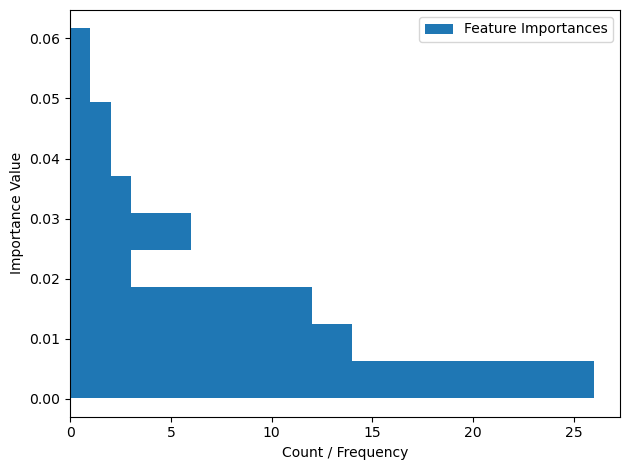

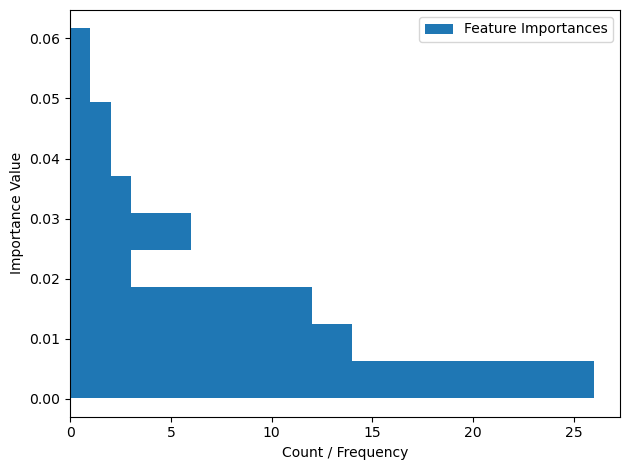

In [17]:
# Extract the physically trained model
trained_model = pipe_3.named_steps["RandomForest"]

displayF_I = feature_importance(trained_model)
displayF_I

### Confusion Matrix (RandomForest)

#### 1. On Test data

In [19]:
y_preds = pipe_3.named_steps["RandomForest"].predict(X_test)
model = pipe_3.named_steps["RandomForest"]



/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


NameError: name 'y' is not defined

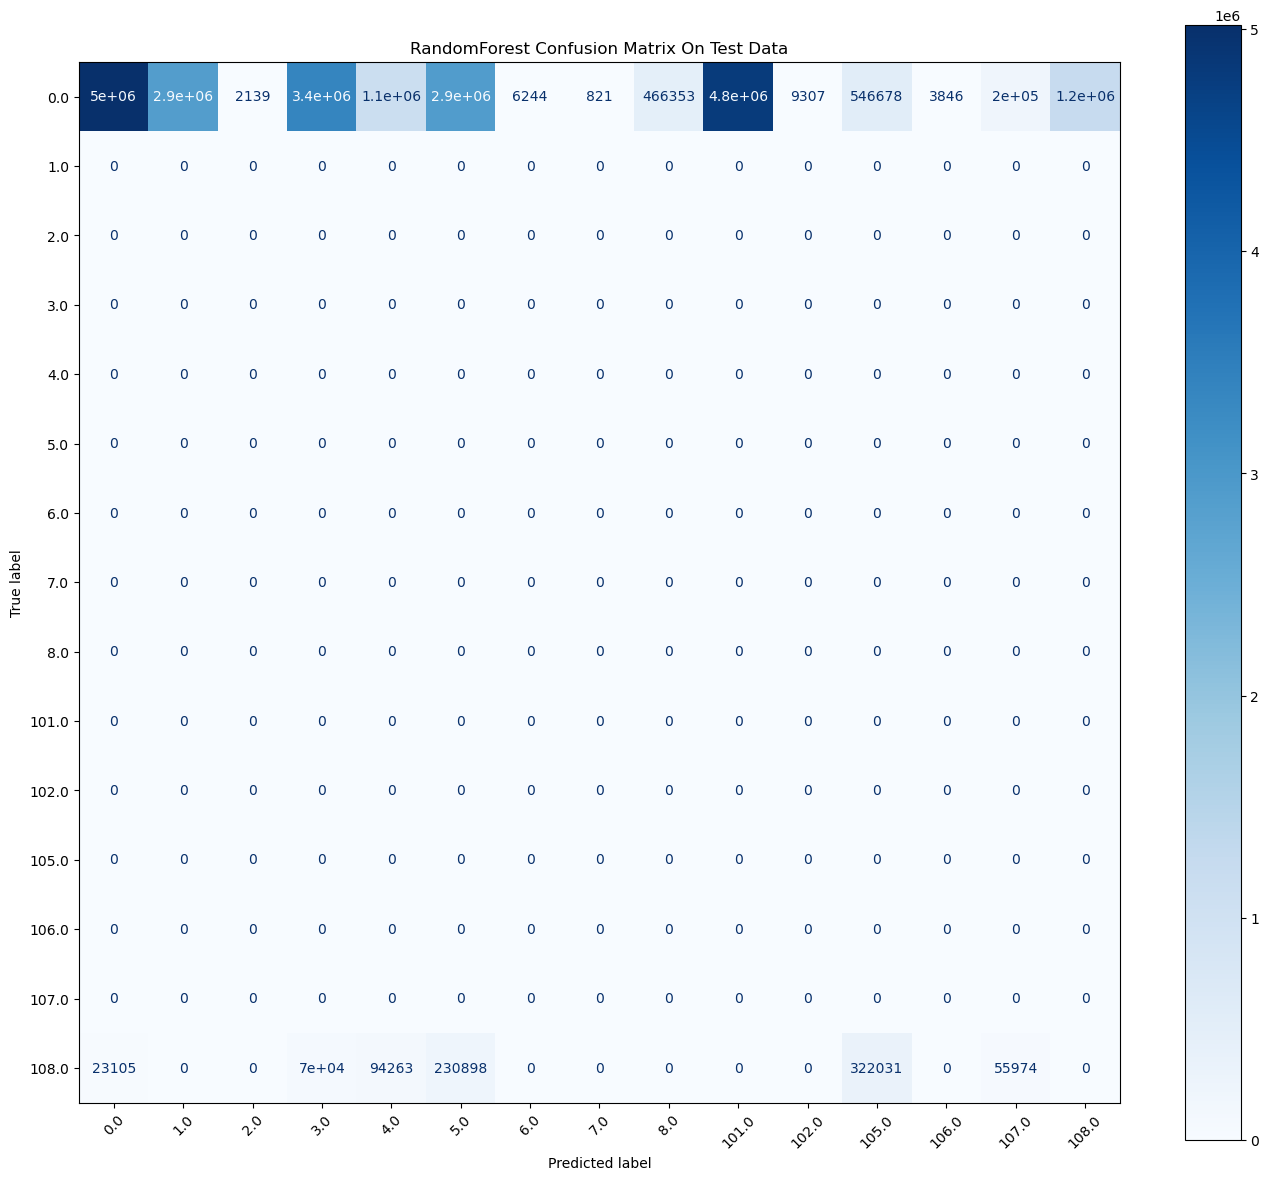

In [21]:
ConfusionMatrix(y_test, y_preds,model=trained_model, model_name="RandomForest")

#### 2. On Train data (to check overfitting)

In [22]:
# 1. Get predicted values on test data
y_preds = pipe_3.named_steps["RandomForest"].predict(X_train)

ConfusionMatrix(y_test, y_preds,model=trained_model, model_name="RandomForest")

/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


ValueError: Found input variables with inconsistent numbers of samples: [20071741, 23332543, 20071741]

### Classification report with Random Forest

In [ ]:
# Creating classification report
report_dict = classification_report(y_test, y_preds, output_dict=True,)

class_report_Random_forest = pd.DataFrame(report_dict).transpose()
class_report_Random_forest.to_csv("../class_report_Random_forest.csv")
class_report_Random_forest

## Model 2: HistGradientBoost

In [10]:
# Split data into X and Y.
X = preprocessed_df.drop(columns="class")
y = preprocessed_df["class"]
group = preprocessed_df["Event_ID"]

In [ ]:
# Instantiate Models
pipe_2 = Pipeline([("Impute", SimpleImputer(strategy="median")),
                   ("RobustScalar", RobustScaler()),
                   ("HistGB", HistGradientBoostingClassifier(class_weight='balanced' ,early_stopping=True ,scoring='recall_macro' ,max_iter = 300,))
                  ])

# Instantiate split class
sgkf = StratifiedGroupKFold(n_splits=3)

# Create a custom scorer that handles the zero division silently
safe_recall_macro = make_scorer(recall_score, average='macro', zero_division=0.0)

# 5. Execute Cross-Validation
print("Starting HistGradBoost cross-validation...")
cv_scores = cross_val_score(
    pipe_2,             
    X,                 
    y,                 
    groups=group,       
    cv=sgkf,            
    scoring=safe_recall_macro,
    n_jobs=1
)

print("===================================")
print(f"Macro Recall Scores: {cv_scores}")
print(f"Average Test Score: {(cv_scores.mean() * 100):.2f}%")

# Final memory cleanup
del X, y, groups
gc.collect()


Starting HistGradBoost cross-validation...


<strong>Classification report with HistGradientBoostClassifier</strong>

In [34]:
# Creating classification report
y_preds_2 = HistGradBoost.predict(X_test)
report_dict = classification_report(y_test, y_preds_2, output_dict=True,)

class_report_2 = pd.DataFrame(report_dict).transpose()
class_report_2.to_csv("../class_report_HistGradBoost.csv")
class_report_2

/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

,precision,recall,f1-score,support
0.0,0.962465,0.756668,0.847248,9.120650e+05
1.0,0.000000,0.000000,0.000000,3.228000e+03
2.0,0.000000,0.000000,0.000000,2.100000e+02
3.0,0.990742,0.775994,0.870317,1.788700e+05
4.0,0.508744,0.900592,0.650194,2.786910e+05
5.0,0.000000,0.000000,0.000000,2.471000e+03
6.0,0.000000,0.000000,0.000000,6.707000e+03
7.0,0.000000,0.000000,0.000000,0.000000e+00
8.0,0.000000,0.000000,0.000000,0.000000e+00
101.0,0.548657,0.449806,0.494338,2.756300e+04


## Observation
RandomForest is not doing too good a job. HistGradientBoostClassfier is performing better. The plan is:

* Tune Hyperparameters of HistGradientBoostClassifier and run RandomizedSearchCv for best params
* Run model with the updated params.
* If model is still not up to 0.9, Importing XGBoost and LighGBM would be the next step.
* If those models still arent enough, Stacking would be employed

Stacking (Stacked Generalization)
Stacking is the evolution of Voting. Instead of just taking a blind average or majority vote of your different models, you train a new meta-model to learn how to best combine their predictions.

In simpler terms: Model 1, 2, and 3 make their predictions. Instead of outputting those, you pass those predictions as the input features to a final Meta-Model (often a simple Logistic Regression). The Meta-Model learns things like: "When Model 1 says 'Cat', it's usually wrong, but when Model 2 says 'Cat', it's usually right, so I will weigh Model 2 heavier."


XGboost, LightGBM and HistGradientBoostClassfier and RandomforestClassifier would be used as the meta-models and will be wrapped around a final LogisticRegression Model

#### Option 1: Tune HistGradientBoostClassifier params

In [53]:
clf_randomcv_score_1 = random_clf_1.score(X_test,y_test)
clf_randomcv_score_1

0.4516392624299427

#### Option 2: Train with XGBoost

In [18]:
# Xgb requires some extra hyperparameter tuning. 
# First, for our imbalanced dataset, compute_sample_weight would be ran to penalize wrongly predicted values on classes with smaller rows like class 7
from sklearn.utils.class_weight import compute_sample_weight


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

XGB = xgb.XGBClassifier(
    objective='multi:softprob',
    tree_method='hist',
    num_class=15,
    eval_metric='mlogloss'
)

# clf_3.fit(X_train,y_train_encoded, sample_weight=weights)
# clf_score_3 = clf_3.score(X_test,y_test_encoded)
# clf_score_3

In [20]:
pipe_2 = Pipeline([ ("RobustScalar", RobustScaler()), ("xgb", XGB)])
pipe_2.fit(X_train, y_train_encoded, xgb__sample_weight=weights)

test_score = pipe_2.score(X_test,y_test)
print("===============================")
print(f"Accuracy score is {test_score}")

cleared_obj = gc.collect()
print(f"Cleared {cleared_objs} trapped objects from RAM")
del cleared_obj

Accuracy score is 0.8202587063380121
Cleared 3276 trapped objects from RAM


<strong>Classification report with XGBoost</strong>